In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
emma_df = pd.read_csv('test_30.csv')
qwen_df = pd.read_csv('qwen_results_v2.csv',
                      na_values='None')
flamingo_df = pd.read_csv('flamingo_results_v2.csv')
voxtral_df = pd.read_csv('voxtral_results_v2.csv',
                      na_values='None')

In [3]:
emotions_col = ['Wonder', 'Transcendence', 'Nostalgia',
                'Tenderness', 'Peacefulness', 'Joy',
                'Power','Tension','Sadness']

In [5]:
flam_emma = []

for emo in emotions_col:

    actual =  emma_df[emo]
    predicted = flamingo_df[emo]

    mae = np.mean(np.abs(actual - predicted))
    mae = mae*100/5 # Mae en % pour comparaison
    flam_emma.append(float(mae))

flam_emma

[15.333333333333334,
 20.0,
 30.0,
 20.666666666666668,
 19.333333333333336,
 30.0,
 22.000000000000004,
 18.666666666666664,
 18.0]

In [6]:
qwen_emma = []

for emo in emotions_col:

    mask = qwen_df[emo].notna()
    actual = emma_df.loc[mask, emo]
    predicted = qwen_df.loc[mask, emo]

    mae = np.mean(np.abs(actual - predicted))
    mae = mae*100/5 # Mae en % pour comparaison
    qwen_emma.append(float(mae))

qwen_emma

[35.862068965517246,
 46.20689655172414,
 25.517241379310345,
 42.06896551724138,
 31.724137931034484,
 28.275862068965516,
 28.275862068965516,
 15.862068965517242,
 24.137931034482758]

In [12]:
voxtral_emma = []

for emo in emotions_col:

    mask = voxtral_df[emo].notna()
    actual = emma_df.loc[mask, emo]
    predicted = voxtral_df.loc[mask, emo]

    mae = np.mean(np.abs(actual - predicted))
    mae = mae*100/5 # Mae en % pour comparaison
    voxtral_emma.append(float(mae))

voxtral_emma

[19.333333333333336,
 16.0,
 22.666666666666664,
 21.333333333333336,
 23.333333333333336,
 38.66666666666667,
 30.666666666666668,
 18.095238095238095,
 22.666666666666664]

In [8]:
# qwen_flamm = []

# for emo in emotions_col:

#     mask = qwen_df[emo].notna()
#     actual = flamingo_df.loc[mask, emo]
#     predicted = qwen_df.loc[mask, emo]

#     mae = np.mean(np.abs(actual - predicted))
#     qwen_flamm.append(float(mae))

# qwen_flamm

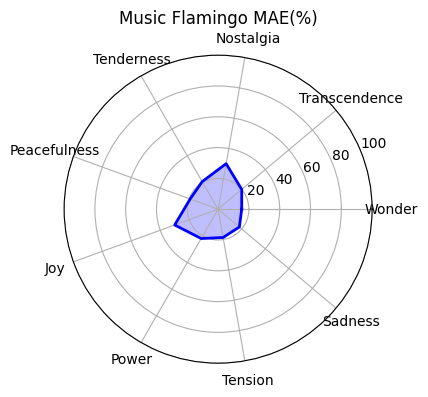

In [9]:
# data
labels = emotions_col
values = flam_emma

# Number of variables
num_vars = len(labels)

# Compute angle of each axis in the plot (in radians)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# The plot is circular, so we need to "complete the loop"
values += values[:1]
angles += angles[:1]

# Create the figure
fig, ax = plt.subplots(figsize=(4, 4), subplot_kw=dict(polar=True))

# Draw the outline of the radar chart
ax.plot(angles, values, color='blue', linewidth=2, linestyle='solid')
ax.fill(angles, values, color='blue', alpha=0.25)

# Set the labels for each axis
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

# Optional: set the range for radial axis
ax.set_ylim(0, 100)

# Add a title
ax.set_title("Music Flamingo MAE(%)", size=12, position=(0.5, 1.1))

# Show the plot
plt.show()


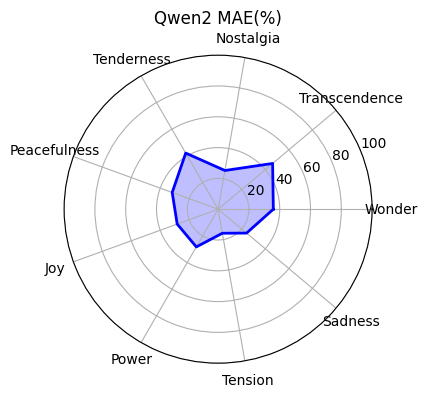

In [10]:
# data
labels = emotions_col
values = qwen_emma

# Number of variables
num_vars = len(labels)

# Compute angle of each axis in the plot (in radians)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# The plot is circular, so we need to "complete the loop"
values += values[:1]
angles += angles[:1]

# Create the figure
fig, ax = plt.subplots(figsize=(4, 4), subplot_kw=dict(polar=True))

# Draw the outline of the radar chart
ax.plot(angles, values, color='blue', linewidth=2, linestyle='solid')
ax.fill(angles, values, color='blue', alpha=0.25)

# Set the labels for each axis
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

# Optional: set the range for radial axis
ax.set_ylim(0, 100)

# Add a title
ax.set_title("Qwen2 MAE(%)", size=12, position=(0.5, 1.1))

# Show the plot
plt.show()


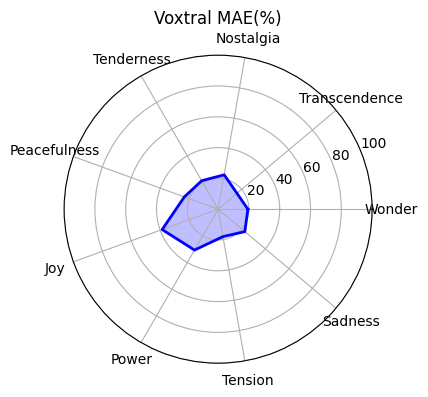

In [13]:
# data
labels = emotions_col
values = voxtral_emma

# Number of variables
num_vars = len(labels)

# Compute angle of each axis in the plot (in radians)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# The plot is circular, so we need to "complete the loop"
values += values[:1]
angles += angles[:1]

# Create the figure
fig, ax = plt.subplots(figsize=(4, 4), subplot_kw=dict(polar=True))

# Draw the outline of the radar chart
ax.plot(angles, values, color='blue', linewidth=2, linestyle='solid')
ax.fill(angles, values, color='blue', alpha=0.25)

# Set the labels for each axis
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

# Optional: set the range for radial axis
ax.set_ylim(0, 100)

# Add a title
ax.set_title("Voxtral MAE(%)", size=12, position=(0.5, 1.1))

# Show the plot
plt.show()
